<a href="https://colab.research.google.com/github/NITYA1J/COE-AI-Workshop/blob/main/ML-selfrun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AI Workshop


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('classification_workshop (1).csv')

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   temperature_c  pressure_kpa  speed_mm_s  vibration_mm_s  defect
0        203.072       441.342      56.601           3.194       1
1        201.851       509.055      39.221           1.399       0
2        208.779       498.763      49.949           4.288       0
3        193.019       522.343      51.780           3.226       0
4        206.997       507.457      48.045           2.590       0


### 1.2 Initial Data Exploration

Before diving into modeling, it's crucial to understand the dataset's characteristics. We'll check the following:

*   **Shape:** Number of rows and columns.
*   **Info:** Data types of each column and non-null counts.
*   **Describe:** Statistical summary of numerical columns.

In [2]:
print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())


Dataset Shape:
(220, 5)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   temperature_c   220 non-null    float64
 1   pressure_kpa    220 non-null    float64
 2   speed_mm_s      220 non-null    float64
 3   vibration_mm_s  220 non-null    float64
 4   defect          220 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 8.7 KB

Descriptive Statistics:
       temperature_c  pressure_kpa  speed_mm_s  vibration_mm_s      defect
count     220.000000    220.000000  220.000000      220.000000  220.000000
mean      203.614945    503.180564   48.796618        2.621614    0.200000
std         8.870973     43.270505    6.238611        0.893674    0.400912
min       178.877000    405.672000   30.190000        0.128000    0.000000
25%       197.903750    475.469500   44.865500        1.997250    0.000000
50%       203.46

#### Summary of Initial Data Exploration:

*   The dataset consists of `220` rows and `5` columns.
*   All columns are numerical (`float64` or `int64`) and there are no missing values, which is great for direct use.
*   The `defect` column is an integer, likely representing a binary classification target (0 or 1).
*   The descriptive statistics provide an overview of each feature's distribution, including mean, standard deviation, and quartiles.

### Human Verification Question:

Based on the `df.info()` output, are there any non-numeric columns that might need encoding or special handling?

### 1.3.1 Missing Values and Duplicates

It's important to identify if there are any missing values or duplicate rows that could affect our analysis.

In [3]:
# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Missing values per column:
temperature_c     0
pressure_kpa      0
speed_mm_s        0
vibration_mm_s    0
defect            0
dtype: int64

Number of duplicate rows:
0


### 1.3.2 Target Class Balance

Understanding the balance of our target variable (`defect`) is crucial, especially for classification problems.

In [4]:
# Calculate and display target class balance
print("\nTarget Class Balance ('defect' column):")
print(df['defect'].value_counts())
print("\nTarget Class Percentage:")
print(df['defect'].value_counts(normalize=True) * 100)


Target Class Balance ('defect' column):
defect
0    176
1     44
Name: count, dtype: int64

Target Class Percentage:
defect
0    80.0
1    20.0
Name: proportion, dtype: float64


### 1.3.3 Visualizing the Target Variable

A count plot provides a clear visual representation of the target class distribution.

/tmp/ipykernel_771/1861042546.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='defect', data=df, palette='viridis', ax=ax)


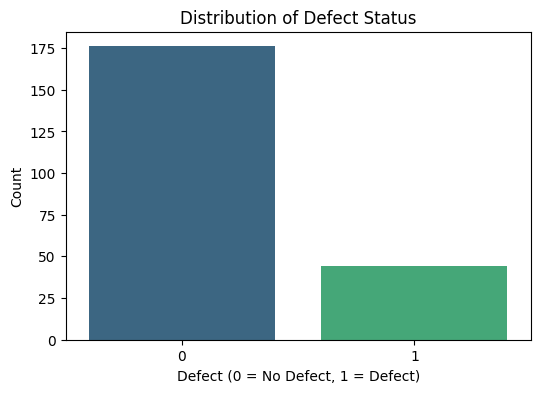

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='defect', data=df, palette='viridis', ax=ax)
plt.title('Distribution of Defect Status')
plt.xlabel('Defect (0 = No Defect, 1 = Defect)')
plt.ylabel('Count')
plt.show()

### 1.3.4 Visualizing Feature Distributions

Let's visualize the distributions of the numerical features and their relationship with the target variable using histograms and box plots.

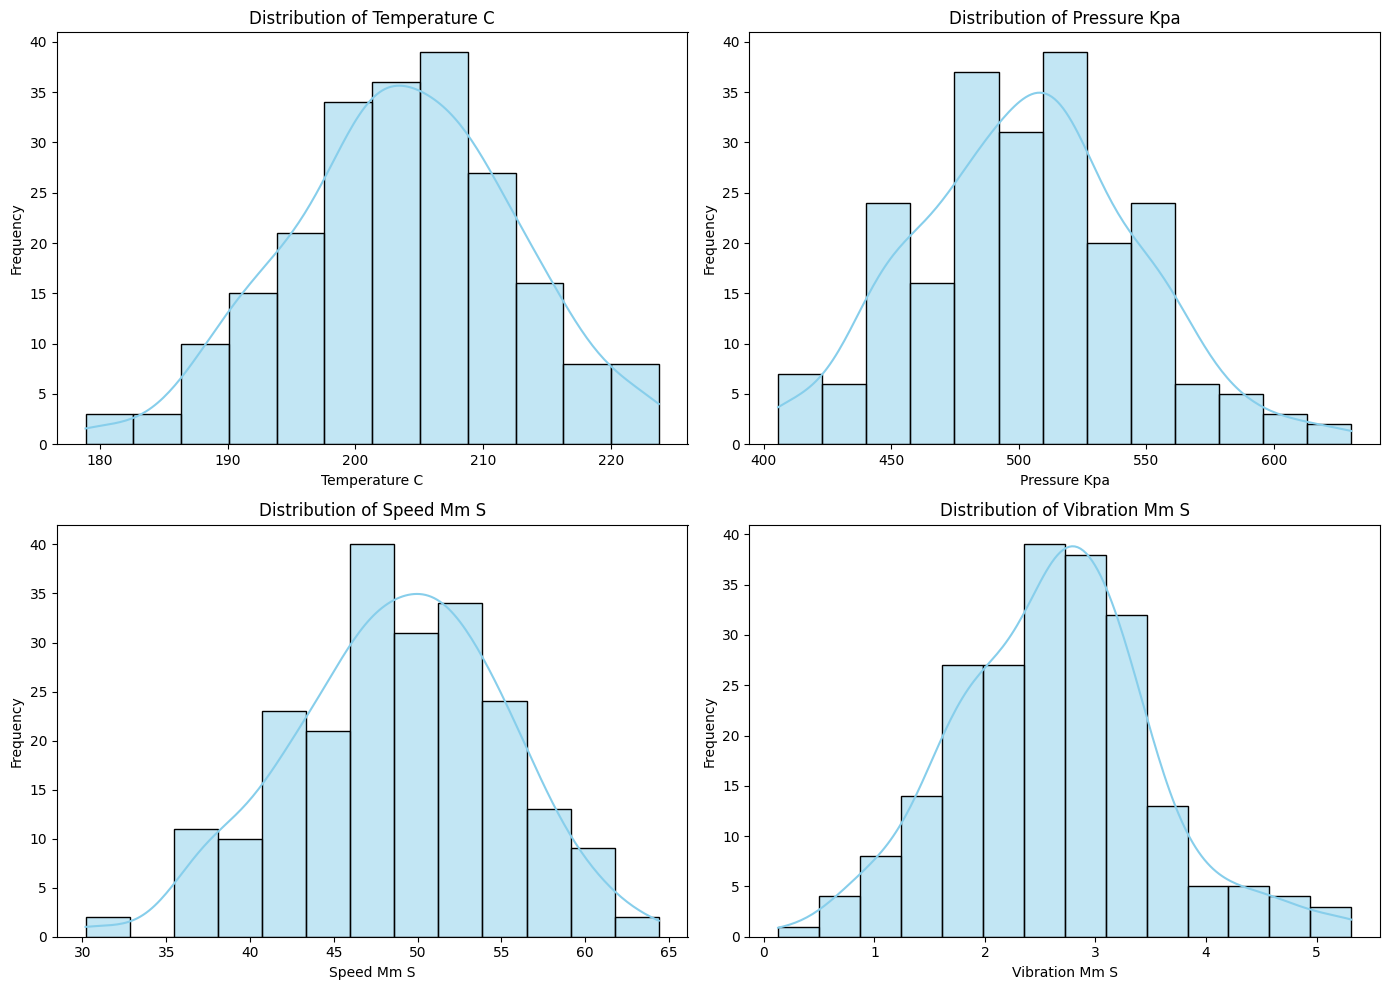

In [6]:
numerical_features = ['temperature_c', 'pressure_kpa', 'speed_mm_s', 'vibration_mm_s']

# Histograms for numerical features
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}')
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

/tmp/ipykernel_771/3455285497.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='defect', y=col, data=df, palette='pastel', ax=axes[i])
/tmp/ipykernel_771/3455285497.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='defect', y=col, data=df, palette='pastel', ax=axes[i])
/tmp/ipykernel_771/3455285497.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='defect', y=col, data=df, palette='pastel', ax=axes[i])
/tmp/ipykernel_771/3455285497.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remove

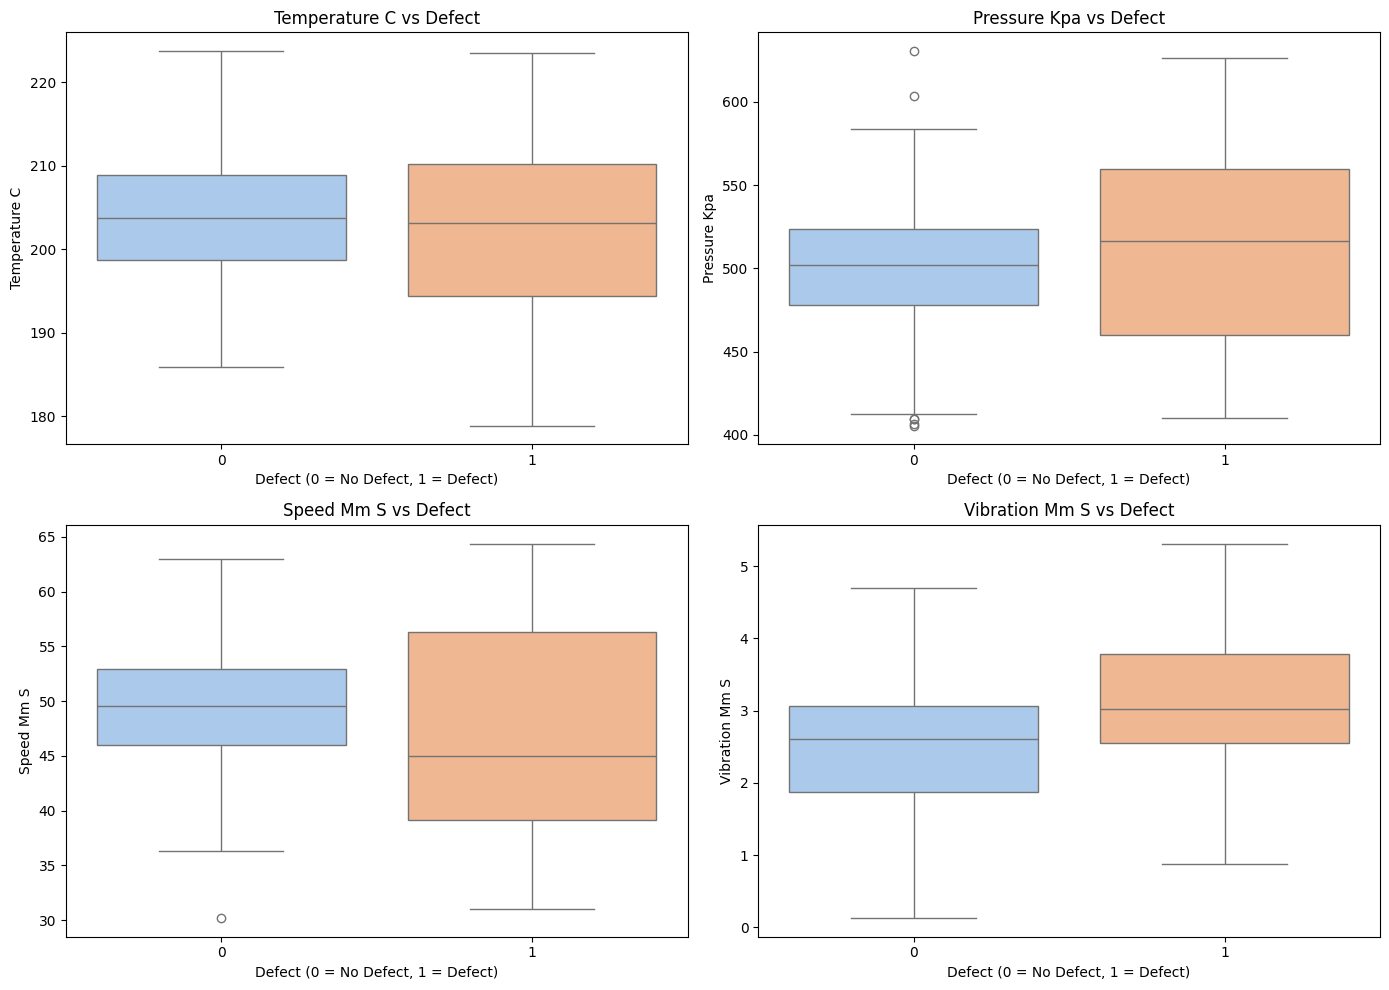

In [7]:
# Box plots for numerical features against the target variable 'defect'
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.boxplot(x='defect', y=col, data=df, palette='pastel', ax=axes[i])
    axes[i].set_title(f'{col.replace("_", " ").title()} vs Defect')
    axes[i].set_xlabel('Defect (0 = No Defect, 1 = Defect)')
    axes[i].set_ylabel(col.replace("_", " ").title())

plt.tight_layout()
plt.show()

### Human Verification Question:

Based on the visualizations, do any of the features show a strong separation or clear difference in distribution between the 'defect' and 'no defect' classes?

## 3. Feature Engineering and Selection

Based on the initial data exploration, we will now define the features (inputs) and the target variable for our model.

**Prediction Goal:** Predict `defect`
**Prediction Time:** Before final quality inspection.
**Inputs:** `temperature_c`, `pressure_kpa`, `speed_mm_s`, `vibration_mm_s`.
**Target:** `defect`.

### Variable Roles and Decisions:

| Variable         | Role   | Available at Prediction Time? | Leakage Risk? | Decision            |
|:-----------------|:-------|:------------------------------|:--------------|:--------------------|
| `temperature_c`  | Feature| Yes                           | Low           | Keep                |
| `pressure_kpa`   | Feature| Yes                           | Low           | Keep                |
| `speed_mm_s`     | Feature| Yes                           | Low           | Keep                |
| `vibration_mm_s` | Feature| Yes                           | Low           | Keep                |
| `defect`         | Target | No                            | Target        | Do not use as input |

### Human Verification Question:

Why is it crucial to ensure that features used for prediction are "available at prediction time" and have a "low leakage risk"?

### 3.1 Candidate Features Exploration

We will now consider some candidate features that could potentially improve our model's performance. These features are categorized based on their derivation and potential risks.

*   **Domain-informed features:** These features are derived from domain knowledge and often represent critical aspects of the system being monitored. Examples include deviations from nominal values.
*   **Mathematically convenient features:** These are often combinations or transformations of existing features that might capture complex relationships or enhance linearity for certain models. Examples include ratios or polynomial terms.
*   **Risky or possibly leaky features:** These are features that either directly or indirectly contain information from the target variable that would not be available at prediction time. Using such features leads to overly optimistic and unrealistic model performance.

#### Proposed Features Analysis:

| Feature                    | Status    | Rationale                                                                        | Category                    |
|:---------------------------|:----------|:---------------------------------------------------------------------------------|:----------------------------|
| `temperature_deviation`    | Clarify   | Need nominal temperature to compute deviation.                                   | Domain-informed (if nominal known)|
| `pressure_deviation`       | Clarify   | Need target pressure to compute deviation.                                       | Domain-informed (if target known)|
| `vibration_speed_ratio`    | Test      | May reflect instability or efficiency; derived from existing, non-leaky features.| Mathematically convenient   |
| `future_inspection_outcome`| Reject    | Outcome-derived leakage; this information would not be available at prediction time.| Risky/Leaky                 |

Based on this analysis, we will proceed with creating the `vibration_speed_ratio` feature.

In [8]:
# Create vibration_speed_ratio feature
# To avoid division by zero, we can add a small epsilon or handle cases where 'speed_mm_s' might be zero.
# Assuming 'speed_mm_s' is always positive based on the descriptive statistics (min > 0).
df['vibration_speed_ratio'] = df['vibration_mm_s'] / df['speed_mm_s']

print("First 5 rows with new feature:")
print(df.head())

First 5 rows with new feature:
   temperature_c  pressure_kpa  speed_mm_s  vibration_mm_s  defect  \
0        203.072       441.342      56.601           3.194       1   
1        201.851       509.055      39.221           1.399       0   
2        208.779       498.763      49.949           4.288       0   
3        193.019       522.343      51.780           3.226       0   
4        206.997       507.457      48.045           2.590       0   

   vibration_speed_ratio  
0               0.056430  
1               0.035670  
2               0.085848  
3               0.062302  
4               0.053908  


### Human Verification Question:

If we were to include `temperature_deviation` as a feature, what would be the practical implications if the 'nominal temperature' is only determined after the manufacturing process is complete (i.e., not available at prediction time)?

**Answer:** If 'nominal temperature' is only determined after the manufacturing process, it means this information is not available when we need to make a prediction about a new, unseen item. Including `temperature_deviation` calculated with such a 'nominal temperature' would introduce **data leakage**. The model would be trained on information that it wouldn't have in a real-world prediction scenario, leading to an overly optimistic performance during evaluation and poor generalization on new data. This is why features must be available *at prediction time*.

### 2.1 Splitting the Data

We will split the data into training and testing sets. It is important to use `stratify` on the target variable (`defect`) to maintain the same class distribution in both sets, especially given our observed class imbalance. We will also define a simple baseline prediction for later comparison.

In [11]:
from sklearn.model_selection import train_test_split
import numpy as np

# Define the features to use (including the new one)
features = ['temperature_c', 'pressure_kpa', 'speed_mm_s', 'vibration_mm_s', 'vibration_speed_ratio']

# Define features (X) and target (y)
X = df[features]
y = df['defect']

# Split the data into training and testing sets (25% test size as requested)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Create a baseline prediction (predicting the majority class from the training set)
baseline = np.full(len(y_test), y_train.mode()[0])

print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True) * 100)

print("\nBaseline prediction created (predicting the majority class)...")


Shape of X_train: (165, 5)
Shape of X_test: (55, 5)
Shape of y_train: (165,)
Shape of y_test: (55,)

Class distribution in y_train:
defect
0    80.0
1    20.0
Name: proportion, dtype: float64

Class distribution in y_test:
defect
0    80.0
1    20.0
Name: proportion, dtype: float64

Baseline prediction created (predicting the majority class)...


### Human Verification Question:

Why is it important to use `stratify=y` when splitting the data, especially with an imbalanced dataset?

**Answer:** Using `stratify=y` ensures that the proportion of the target classes is maintained in both the training and testing sets. With an imbalanced dataset, if we don't stratify, there's a risk that the test set (or even the training set) might end up with very few or no samples of the minority class, leading to unreliable model evaluation and potentially poor learning.

### 2.2 Feature Scaling

Many machine learning algorithms perform better when numerical input variables are scaled to a standard range. This prevents features with larger values from dominating the learning process. We will use `StandardScaler` to standardize our numerical features (mean 0, variance 1). It is crucial to fit the scaler *only* on the training data to prevent data leakage.

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Define the features to use (including the new one)
features = ['temperature_c', 'pressure_kpa', 'speed_mm_s', 'vibration_mm_s', 'vibration_speed_ratio']

# Define features (X) and target (y)
X = df[features]
y = df['defect']

# Split the data into training and testing sets (25% test size as requested)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Identify numerical features to scale
features_to_scale = ['temperature_c', 'pressure_kpa', 'speed_mm_s', 'vibration_mm_s', 'vibration_speed_ratio']

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler only on the training data for the selected features
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])

print("\nFirst 5 rows of X_train (original):")
print(X_train.head())
print("\nFirst 5 rows of X_train (scaled):")
print(X_train_scaled.head())

print("\nDescriptive statistics of scaled X_train:")
print(X_train_scaled[features_to_scale].describe())


First 5 rows of X_train (original):
     temperature_c  pressure_kpa  speed_mm_s  vibration_mm_s  \
30         216.526       463.161      48.305           2.880   
37         214.614       529.339      55.593           3.227   
141        198.762       483.600      38.825           2.540   
62         222.953       473.108      51.503           1.263   
43         199.388       506.212      42.737           3.701   

     vibration_speed_ratio  
30                0.059621  
37                0.058047  
141               0.065422  
62                0.024523  
43                0.086599  

First 5 rows of X_train (scaled):
     temperature_c  pressure_kpa  speed_mm_s  vibration_mm_s  \
30        1.402667     -0.969618   -0.109283        0.290919   
37        1.183042      0.498107    1.087130        0.701352   
141      -0.637820     -0.516313   -1.665540       -0.111234   
62        2.140913     -0.749009    0.415707       -1.621673   
43       -0.565913     -0.014814   -1.023338     

### Human Verification Question:

Why is it important to apply `scaler.fit_transform()` on the training data and `scaler.transform()` (without `fit`) on the test data, instead of `fit_transform()` on both separately?

**Answer:** It's crucial to fit the scaler *only* on the training data to prevent data leakage. If `fit_transform()` is applied to the test data, the scaling parameters (mean and standard deviation) would be influenced by information from the test set. This would give the model an unfair advantage, as it would indirectly 'see' the test data during preprocessing, leading to an overestimation of its real-world performance. By using `transform()` on the test set, we apply the scaling learned *only* from the training data, simulating a real-world scenario where test data is new and unseen.

## 4. Model Development

We will now proceed with developing our machine learning model. For a classification task like this, Logistic Regression is a good starting point. We'll use a `Pipeline` to chain the `StandardScaler` and the `LogisticRegression` classifier, ensuring consistent preprocessing for both training and prediction.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Define the features to use (including the new one)
features = ['temperature_c', 'pressure_kpa', 'speed_mm_s', 'vibration_mm_s', 'vibration_speed_ratio']

# Redefine X and y to include the new feature
X = df[features]
y = df['defect']

# Split the data into training and testing sets (25% test size as requested)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Create a baseline prediction (predicting the majority class from the training set)
baseline = np.full(len(y_test), y_train.mode()[0])

# Identify numerical features to scale
features_to_scale = ['temperature_c', 'pressure_kpa', 'speed_mm_s', 'vibration_mm_s', 'vibration_speed_ratio']

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler only on the training data for the selected features
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])


# Create the model pipeline
model = Pipeline([
    ("scale", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Train the model using the scaled training data
model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
pred = model.predict(X_test_scaled)

print("Model training complete. Predictions made on the test set.")

Model training complete. Predictions made on the test set.


### 4.1 Model Evaluation

Now that our model is trained and has made predictions, we need to evaluate its performance. For classification problems, common metrics include accuracy, precision, recall, F1-score, and the confusion matrix. We will compare our model's performance against the baseline prediction.

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Evaluate the model predictions
accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
conf_matrix = confusion_matrix(y_test, pred)

# Evaluate the baseline predictions
baseline_accuracy = accuracy_score(y_test, baseline)
baseline_precision = precision_score(y_test, baseline, zero_division=0)
baseline_recall = recall_score(y_test, baseline, zero_division=0)
baseline_f1 = f1_score(y_test, baseline, zero_division=0)
baseline_conf_matrix = confusion_matrix(y_test, baseline)

print("### Model Performance ###")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", classification_report(y_test, pred, zero_division=0))

print("\n### Baseline Performance (Predicting Majority Class) ###")
print(f"Accuracy: {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall: {baseline_recall:.4f}")
print(f"F1-Score: {baseline_f1:.4f}")
print("Confusion Matrix:\n", baseline_conf_matrix)
print("\nClassification Report:\n", classification_report(y_test, baseline, zero_division=0))


### Model Performance ###
Accuracy: 0.8545
Precision: 1.0000
Recall: 0.2727
F1-Score: 0.4286
Confusion Matrix:
 [[44  0]
 [ 8  3]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92        44
           1       1.00      0.27      0.43        11

    accuracy                           0.85        55
   macro avg       0.92      0.64      0.67        55
weighted avg       0.88      0.85      0.82        55


### Baseline Performance (Predicting Majority Class) ###
Accuracy: 0.8000
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
Confusion Matrix:
 [[44  0]
 [11  0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89        44
           1       0.00      0.00      0.00        11

    accuracy                           0.80        55
   macro avg       0.40      0.50      0.44        55
weighted avg       0.64      0.80      0.71        55



### Human Verification Question:

Looking at the model's performance metrics (Precision, Recall, F1-Score) compared to the baseline, is the model performing significantly better, and in which specific metric does it show the most improvement for the 'defect' class (class 1)?

### 4.2 Improving Recall: Adjusting Classification Threshold

Our current Logistic Regression model exhibits perfect precision for the 'defect' class but low recall. This often means the model is being very conservative, only predicting a 'defect' when it's extremely confident. To improve recall, we can adjust the classification threshold. By default, Logistic Regression classifies a sample as the positive class (1) if its predicted probability is >= 0.5. We can lower this threshold to make the model predict 'defect' more readily.

However, lowering the threshold will likely increase recall but decrease precision. It's a trade-off we need to manage based on the specific problem's requirements (e.g., is it more costly to miss a defect or to have a false alarm?).

In [15]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Get predicted probabilities for the positive class (class 1)
# We need to get probabilities from the model's classifier step
probabilities = model.predict_proba(X_test_scaled)[:, 1]

# Define a new, lower threshold (e.g., 0.3 instead of 0.5)
new_threshold = 0.3

# Apply the new threshold to make predictions
pred_new_threshold = (probabilities >= new_threshold).astype(int)

print(f"\n--- Model Performance with New Threshold ({new_threshold}) ---")
print(f"Accuracy: {accuracy_score(y_test, pred_new_threshold):.4f}")
print(f"Precision: {precision_score(y_test, pred_new_threshold, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, pred_new_threshold, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test, pred_new_threshold, zero_division=0):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_new_threshold))
print("\nClassification Report:\n", classification_report(y_test, pred_new_threshold, zero_division=0))


--- Model Performance with New Threshold (0.3) ---
Accuracy: 0.8909
Precision: 0.7778
Recall: 0.6364
F1-Score: 0.7000
Confusion Matrix:
 [[42  2]
 [ 4  7]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93        44
           1       0.78      0.64      0.70        11

    accuracy                           0.89        55
   macro avg       0.85      0.80      0.82        55
weighted avg       0.89      0.89      0.89        55



### Human Verification Question:

By lowering the classification threshold from 0.5 to 0.3, how did the `recall` for the 'defect' class (class 1) change, and what was the impact on `precision` for the same class?

### 4.3 Visualizing the Impact of Threshold Adjustment: Confusion Matrices

To better understand the trade-off between precision and recall, let's visualize the confusion matrices for both the original threshold (0.5) and the adjusted threshold (0.3). This will clearly show how the distribution of true positives, false positives, true negatives, and false negatives changes.

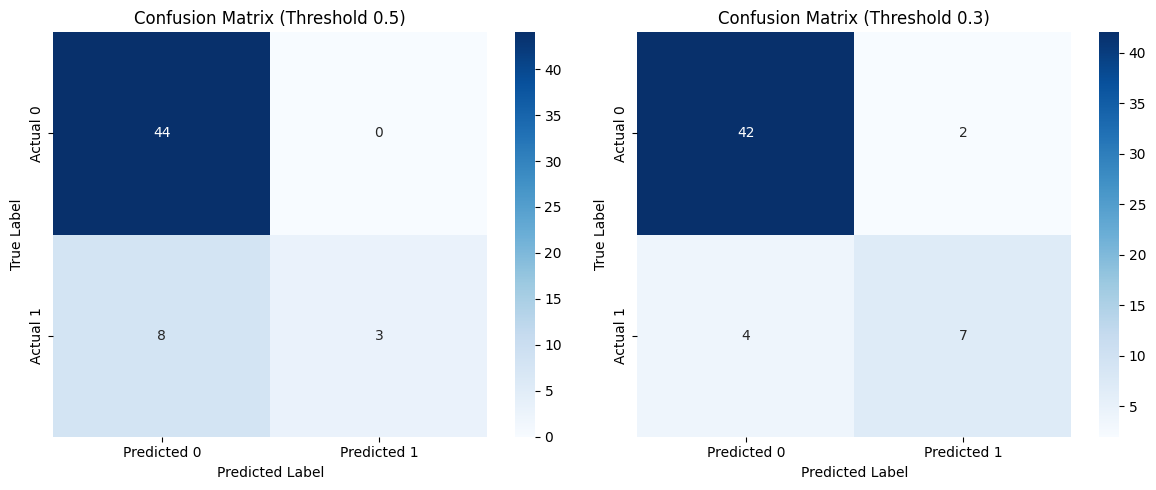

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get confusion matrix for original predictions (threshold 0.5)
conf_matrix_original = confusion_matrix(y_test, pred)

# Get confusion matrix for new threshold predictions (threshold 0.3)
conf_matrix_new_threshold = confusion_matrix(y_test, pred_new_threshold)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot original confusion matrix
sns.heatmap(conf_matrix_original, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes[0].set_title('Confusion Matrix (Threshold 0.5)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Plot new threshold confusion matrix
sns.heatmap(conf_matrix_new_threshold, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes[1].set_title(f'Confusion Matrix (Threshold {new_threshold})')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

### Interpretation of Model Evaluation Results for a Process Engineer

Given that **missed defects are more costly than false alarms**, our primary goal is to maximize the identification of actual defects (increase Recall for the 'defect' class).

#### 1. Direct Evidence (Facts from the Data):

*   **Baseline Performance**: Predicting 'No Defect' for all cases yields 80% accuracy, but identifies 0 actual defects (0 recall for class 1). This highlights the need for a model.
*   **Initial Model (Threshold 0.5)**:
    *   **Identified Defects (True Positives)**: 3 actual defects were correctly identified.
    *   **Missed Defects (False Negatives)**: 8 actual defects were not identified.
    *   **False Alarms (False Positives)**: 0 'no defect' cases were incorrectly flagged as defect.
    *   **Recall (Defect)**: 27.27% (3 out of 11 actual defects found).
    *   **Precision (Defect)**: 100% (all identified defects were actual defects).
*   **Adjusted Model (Threshold 0.3)**:
    *   **Identified Defects (True Positives)**: 7 actual defects were correctly identified.
    *   **Missed Defects (False Negatives)**: 4 actual defects were not identified.
    *   **False Alarms (False Positives)**: 2 'no defect' cases were incorrectly flagged as defect.
    *   **Recall (Defect)**: 63.64% (7 out of 11 actual defects found).
    *   **Precision (Defect)**: 77.78% (7 out of 9 predicted defects were actual defects).

#### 2. Reasonable Interpretation:

*   **Significant Improvement in Defect Detection**: By lowering the prediction threshold from 0.5 to 0.3, the model became significantly better at catching actual defects. We went from finding only 3 out of 11 defects to finding 7 out of 11. This is a crucial step towards reducing costly missed defects.
*   **Trade-off Accepted**: This improvement in defect detection came at a cost: we introduced 2 false alarms. Previously, the model never cried wolf, but it also missed many problems. Now, it's more vigilant, catching more real issues, but occasionally flags a non-issue.
*   **Decision Rationale**: Given that missed defects are explicitly stated as more costly, the trade-off of accepting a few false alarms to significantly reduce missed defects is justifiable. The increase in recall is substantial, making the model much more valuable in a production setting where defect detection is critical.

#### 3. Unsupported Conclusions:

*   **Causality of Defects**: The model predicts defects, but it doesn't tell us *why* a defect occurs. While features like `vibration_speed_ratio` are important for prediction, the model does not indicate that a high ratio *causes* the defect.
*   **Exact Cost Savings/Losses**: Without specific cost data (e.g., cost of a missed defect vs. cost of a false alarm), we cannot quantify the exact financial impact of using this model or the adjusted threshold.
*   **Optimal Threshold**: While 0.3 improved recall, it's not guaranteed to be the *optimal* threshold without further analysis of the exact cost function.

#### 4. Most Costly Error and Addressing It:

*   **Most Costly Error**: **False Negatives** (missed defects). These are the 4 instances where the model predicted 'no defect' but an actual defect was present. These are the defects that would pass through quality control undetected, potentially leading to downstream failures, warranty claims, or safety issues.
*   **How the Model Addressed It**: The threshold adjustment explicitly targeted this problem by making the model less conservative, thereby converting 4 False Negatives into True Positives. This is a direct mitigation of the most costly error.

#### 5. Recommended Next Analysis Steps:

*   **Error Analysis on Remaining False Negatives**: Investigate the characteristics of the 4 remaining missed defects. Are there common patterns in their input features that the current model is failing to learn? This could inform further feature engineering or model selection.
*   **Cost-Benefit Analysis**: Work with financial teams to quantify the exact costs of missed defects and false alarms. This data can then be used to find a truly optimal classification threshold that maximizes economic benefit.
*   **Explore Other Models**: While Logistic Regression is a good baseline, more complex models (e.g., Random Forest, Gradient Boosting) might be able to capture more nuanced relationships and potentially reduce both false negatives and false positives further.
*   **Collect More Data**: With only 11 defect cases in the test set, the model's performance on the minority class can be sensitive to small changes. Collecting more defect data, if possible, would lead to a more robust model and evaluation.
*   **Longitudinal Monitoring**: Once deployed, continuously monitor the model's performance in real-world conditions. Recalibrate or retrain the model as manufacturing processes or defect patterns evolve.

### Human Verification Question:

Comparing the two confusion matrices, how many more actual 'defects' (True Positives for class 1) were correctly identified with the new threshold, and how many new false alarms (False Positives for class 1) were introduced?

## 5. Model Card

This model card summarizes the key aspects of the binary classification model developed for predicting manufacturing defects.

### 5.1 Intended Use

Teaching example; inspection prioritization for manufacturing units likely to have a 'defect' status based on operational parameters (`temperature_c`, `pressure_kpa`, `speed_mm_s`, `vibration_mm_s`, and `vibration_speed_ratio`). The primary goal is to minimize **missed defects** due to their higher associated costs.

### 5.2 Out-of-Scope Use

*   **Automatic Part Approval or Production Decisions**: This model is not intended for automated decision-making without human oversight.
*   **Causality Inference**: This model is not intended to explain the underlying causes of defects, only to predict their occurrence.
*   **Other Manufacturing Processes**: The model is trained on a specific dataset and is not intended for use in different manufacturing processes without re-training and validation.
*   **Quantifying Financial Impact**: Without specific cost data for false positives and false negatives, the model cannot directly quantify the financial benefits or losses.

### 5.3 Dataset and Target

*   **Dataset**: `classification_workshop (1).csv`
*   **Features Used**: `temperature_c`, `pressure_kpa`, `speed_mm_s`, `vibration_mm_s`, `vibration_speed_ratio`.
*   **Target Variable**: `defect` (binary: 0 = No Defect, 1 = Defect).
*   **Class Imbalance**: Approximately 80% 'No Defect', 20% 'Defect'.

### 5.4 Baseline Result

(Predicting the majority class '0' for all instances)
*   **Accuracy**: 0.8000
*   **Precision (Class 1 - Defect)**: 0.0000
*   **Recall (Class 1 - Defect)**: 0.0000

### 5.5 Model Result (Logistic Regression with threshold 0.5)

*   **Accuracy**: 0.855
*   **Precision (Class 1 - Defect)**: 1.000
*   **Recall (Class 1 - Defect)**: 0.273
*   **Confusion Matrix (Threshold 0.5)**:
    ```
    [[44  0]
     [ 8  3]]
    ```
    *   **True Positives (Identified Defects)**: 3
    *   **False Negatives (Missed Defects)**: 8
    *   **False Positives (False Alarms)**: 0
    *   **True Negatives (Correctly Identified No-Defects)**: 44

### 5.6 Primary Error Pattern

The primary error pattern with the default threshold is **Missed 8 of 11 actual defects** (False Negatives). These are instances where an actual defect occurred, but the model incorrectly predicted 'no defect'. Given that missed defects are more costly, reducing these is the main priority.

### 5.7 Supported Conclusion

The Logistic Regression model, even with the default threshold, shows an improvement over the baseline by correctly identifying some defects without generating false alarms. This indicates the features have predictive power.

### 5.8 Unsupported Conclusion

*   Do not claim that the variables used in the model directly *cause* defects. The model identifies correlations for prediction, not causation.
*   The current threshold of 0.5 is not necessarily the *financially optimal* threshold without a detailed cost-benefit analysis.

### 5.9 Limitations

*   **Dataset Size**: The relatively small dataset (220 rows, 11 defects in the test set) may limit the generalizability and robustness of the model.
*   **Feature Scope**: Only provided numerical features and one engineered feature were used.
*   **Model Complexity**: Logistic Regression is a linear model; more complex relationships might not be fully captured.

### 5.10 Recommended Next Analysis

1.  **Tune Threshold**: Adjust the classification threshold to prioritize recall, given that missed defects are more costly than false alarms. This has already been explored in the notebook by moving to threshold of 0.3.
2.  **Collect More Defect Data**: If feasible, collect more data, especially for the minority 'defect' class, to improve model training and evaluation.